# Prep

Load Data

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('nutrition_labeled.csv')

print(df.shape)
print(df.dtypes)
print(df.head())
print(df.describe())

(3454, 26)
Vitamin C (mg per 100g)       float64
Vitamin B11 (mg per 100g)     float64
Sodium (mg per 100g)          float64
Calcium (mg per 100g)         float64
Carbohydrates (g per 100g)    float64
food                           object
Iron (mg per 100g)            float64
Calories (kcal per 100g)      float64
Sugars (g per 100g)           float64
Dietary Fiber (g per 100g)    float64
Fat (g per 100g)              float64
Protein (g per 100g)          float64
food_normalized                object
is_vegetarian                    bool
is_vegan                         bool
is_halal                         bool
is_gluten_free                   bool
is_lactose_free                  bool
is_nut_free                      bool
allergen_peanut                  bool
allergen_milk                    bool
allergen_egg                     bool
allergen_fish                    bool
allergen_shellfish               bool
allergen_soy                     bool
allergen_wheat                   bool
d

In [3]:
print(df.isnull().sum())

Vitamin C (mg per 100g)       0
Vitamin B11 (mg per 100g)     0
Sodium (mg per 100g)          0
Calcium (mg per 100g)         0
Carbohydrates (g per 100g)    0
food                          0
Iron (mg per 100g)            0
Calories (kcal per 100g)      0
Sugars (g per 100g)           0
Dietary Fiber (g per 100g)    0
Fat (g per 100g)              0
Protein (g per 100g)          0
food_normalized               0
is_vegetarian                 0
is_vegan                      0
is_halal                      0
is_gluten_free                0
is_lactose_free               0
is_nut_free                   0
allergen_peanut               0
allergen_milk                 0
allergen_egg                  0
allergen_fish                 0
allergen_shellfish            0
allergen_soy                  0
allergen_wheat                0
dtype: int64


Feature Engineering

Nutrition Tags

In [4]:
df['high_protein'] = (
    df['Protein (g per 100g)'] >= 20
)

df['low_fat'] = (
    df['Fat (g per 100g)'] <= 5
)

df['low_carb'] = (
    df['Carbohydrates (g per 100g)'] <= 10
)

df['high_calorie'] = (
    df['Calories (kcal per 100g)'] >= 300
)

Check

In [5]:
print(df[
    [
        'high_protein',
        'low_fat',
        'low_carb',
        'high_calorie',
    ]
].head(50))

    high_protein  low_fat  low_carb  high_calorie
0          False    False      True         False
1          False    False      True         False
2          False    False      True         False
3          False    False      True          True
4          False    False      True         False
5          False    False      True         False
6          False    False      True         False
7          False    False      True         False
8          False    False      True         False
9          False    False      True         False
10         False    False      True         False
11         False    False      True         False
12         False    False      True         False
13         False    False      True         False
14         False     True      True         False
15         False    False      True         False
16         False    False      True         False
17         False    False      True         False
18         False    False      True         False


Clean Food Name

In [6]:
df['food_clean'] = (
    df['food']
    .astype(str)
    .str.lower()
    .str.strip()
)

In [7]:
print(df.columns)

Index(['Vitamin C (mg per 100g)', 'Vitamin B11 (mg per 100g)',
       'Sodium (mg per 100g)', 'Calcium (mg per 100g)',
       'Carbohydrates (g per 100g)', 'food', 'Iron (mg per 100g)',
       'Calories (kcal per 100g)', 'Sugars (g per 100g)',
       'Dietary Fiber (g per 100g)', 'Fat (g per 100g)',
       'Protein (g per 100g)', 'food_normalized', 'is_vegetarian', 'is_vegan',
       'is_halal', 'is_gluten_free', 'is_lactose_free', 'is_nut_free',
       'allergen_peanut', 'allergen_milk', 'allergen_egg', 'allergen_fish',
       'allergen_shellfish', 'allergen_soy', 'allergen_wheat', 'high_protein',
       'low_fat', 'low_carb', 'high_calorie', 'food_clean'],
      dtype='object')


Rule Based

In [8]:
class NutritionCalculator:

    # BMR CALCULATION
    def calculate_bmr(
        self,
        gender,
        weight,
        height,
        age
    ):

        # Mifflin St Jeor Formula

        if gender.lower() == 'male':

            bmr = (
                10 * weight
                +
                6.25 * height
                -
                5 * age
                +
                5
            )

        else:

            bmr = (
                10 * weight
                +
                6.25 * height
                -
                5 * age
                -
                161
            )

        return round(bmr, 2)

    # TDEE CALCULATION
    def calculate_tdee(
        self,
        bmr,
        activity_level
    ):

        activity_multiplier = {

            'sedentary': 1.2,

            'light': 1.375,

            'moderate': 1.55,

            'active': 1.725,

            'very_active': 1.9
        }

        tdee = (
            bmr *
            activity_multiplier[activity_level]
        )

        return round(tdee, 2)

    # CALORIE TARGET
    def calculate_calorie_target(
        self,
        tdee,
        goal
    ):

        if goal == 'weight_loss':

            calorie_target = tdee - 500

        elif goal == 'weight_gain':

            calorie_target = tdee + 300

        else:

            calorie_target = tdee

        return round(calorie_target, 2)

    # MACRONUTRIENT TARGET
    def calculate_macros(
        self,
        calorie_target
    ):

        # Distribution:
        # Protein = 30%
        # Fat = 25%
        # Carbs = 45%

        protein_calories = (
            calorie_target * 0.30
        )

        fat_calories = (
            calorie_target * 0.25
        )

        carbs_calories = (
            calorie_target * 0.45
        )

        protein_g = (
            protein_calories / 4
        )

        fat_g = (
            fat_calories / 9
        )

        carbs_g = (
            carbs_calories / 4
        )

        return {

            'protein_g': round(protein_g, 2),

            'fat_g': round(fat_g, 2),

            'carbs_g': round(carbs_g, 2)
        }

Rule Based Testing

In [9]:
calculator = NutritionCalculator()

gender = 'male'
weight = 85
height = 170
age = 21

activity_level = 'sedentary'
goal = 'weight_loss'

bmr = calculator.calculate_bmr(
    gender,
    weight,
    height,
    age
)

tdee = calculator.calculate_tdee(
    bmr,
    activity_level
)

calorie_target = (
    calculator.calculate_calorie_target(
        tdee,
        goal
    )
)

macros = calculator.calculate_macros(
    calorie_target
)

print(f"BMR: {round(bmr, 2)} kcal")

print(f"TDEE: {round(tdee, 2)} kcal")

print(f"Target Calories: {round(calorie_target, 2)} kcal")

print("\nMacro Targets:")

print(macros)

BMR: 1812.5 kcal
TDEE: 2175.0 kcal
Target Calories: 1675.0 kcal

Macro Targets:
{'protein_g': 125.62, 'fat_g': 46.53, 'carbs_g': 188.44}


# DEEP LEARNING NUTRITION PREDICTION MODEL

Load User Training Dataset

In [10]:
user_df = pd.read_csv('/content/training_data_for_ai_engineer.csv')

duplicate_cols = ['protein_target_g.1', 'fat_target_g.1', 'carbs_target_g.1']
duplicate_cols = [col for col in duplicate_cols if col in user_df.columns]

if duplicate_cols:
    user_df = user_df.drop(columns=duplicate_cols)

print("Shape user_df:", user_df.shape)
print(user_df.columns.tolist())
user_df.head()

Shape user_df: (500, 18)
['gender', 'weight_kg', 'height_cm', 'age', 'activity_level', 'goal', 'gender_encoded', 'activity_encoded', 'goal_encoded', 'weight_kg_scaled', 'height_cm_scaled', 'age_scaled', 'bmr', 'tdee', 'calorie_goal', 'protein_target_g', 'fat_target_g', 'carbs_target_g']


,gender,weight_kg,height_cm,age,activity_level,goal,gender_encoded,activity_encoded,goal_encoded,weight_kg_scaled,height_cm_scaled,age_scaled,bmr,tdee,calorie_goal,protein_target_g,fat_target_g,carbs_target_g
0,male,86.4,151.9,48,sedentary,gain,1,3,0,0.753676,0.054286,0.731707,1702.33,2042.80,2342.80,175.7,65.1,263.6
1,female,79.1,168.2,45,sedentary,gain,0,3,0,0.619485,0.520000,0.658537,1505.26,1806.31,2106.31,158.0,58.5,237.0
2,male,68.9,163.4,28,extra_active,gain,1,0,0,0.431985,0.382857,0.243902,1636.62,3109.58,3409.58,255.7,94.7,383.6
3,male,74.3,166.6,18,moderately_active,maintain,1,2,2,0.531250,0.474286,0.000000,1781.09,2760.69,2760.69,207.1,92.0,276.1
4,male,85.8,184.4,55,sedentary,lose,1,3,1,0.742647,0.982857,0.902439,1810.53,2172.64,1672.64,146.4,55.8,146.4


In [11]:
duplicate_cols = ['protein_target_g.1', 'fat_target_g.1', 'carbs_target_g.1']
duplicate_cols = [col for col in duplicate_cols if col in user_df.columns]

if duplicate_cols:
    user_df = user_df.drop(columns=duplicate_cols)

print("Shape user_df:", user_df.shape)
print("Columns:")
print(user_df.columns.tolist())
user_df.head()

Shape user_df: (500, 18)
Columns:
['gender', 'weight_kg', 'height_cm', 'age', 'activity_level', 'goal', 'gender_encoded', 'activity_encoded', 'goal_encoded', 'weight_kg_scaled', 'height_cm_scaled', 'age_scaled', 'bmr', 'tdee', 'calorie_goal', 'protein_target_g', 'fat_target_g', 'carbs_target_g']


,gender,weight_kg,height_cm,age,activity_level,goal,gender_encoded,activity_encoded,goal_encoded,weight_kg_scaled,height_cm_scaled,age_scaled,bmr,tdee,calorie_goal,protein_target_g,fat_target_g,carbs_target_g
0,male,86.4,151.9,48,sedentary,gain,1,3,0,0.753676,0.054286,0.731707,1702.33,2042.80,2342.80,175.7,65.1,263.6
1,female,79.1,168.2,45,sedentary,gain,0,3,0,0.619485,0.520000,0.658537,1505.26,1806.31,2106.31,158.0,58.5,237.0
2,male,68.9,163.4,28,extra_active,gain,1,0,0,0.431985,0.382857,0.243902,1636.62,3109.58,3409.58,255.7,94.7,383.6
3,male,74.3,166.6,18,moderately_active,maintain,1,2,2,0.531250,0.474286,0.000000,1781.09,2760.69,2760.69,207.1,92.0,276.1
4,male,85.8,184.4,55,sedentary,lose,1,3,1,0.742647,0.982857,0.902439,1810.53,2172.64,1672.64,146.4,55.8,146.4


# REVISI AI ENGINEER - MODEL Feat:1
*Adi Bayu Saputra*

In [12]:
import os
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.layers import Input, Dense, BatchNormalization
from tensorflow.keras.models import Model

cek kategori

In [13]:
print("Unique gender:", user_df['gender'].unique())
print("Unique activity_level:", user_df['activity_level'].unique())
print("Unique goal:", user_df['goal'].unique())

Unique gender: ['male' 'female']
Unique activity_level: ['sedentary' 'extra_active' 'moderately_active' 'very_active'
 'lightly_active']
Unique goal: ['gain' 'maintain' 'lose']


feature dan target

In [14]:
feature_cols = [
    'gender', 'weight_kg', 'height_cm', 'age',
    'activity_level', 'goal', 'bmr', 'tdee'
]

target_cols = ['calorie_goal', 'protein_target_g', 'fat_target_g', 'carbs_target_g']

X_df = user_df[feature_cols].copy()
y_df = user_df[target_cols].copy()

print("X shape:", X_df.shape)
print("y shape:", y_df.shape)
display(X_df.head())
display(y_df.head())

X shape: (500, 8)
y shape: (500, 4)


,gender,weight_kg,height_cm,age,activity_level,goal,bmr,tdee
0,male,86.4,151.9,48,sedentary,gain,1702.33,2042.80
1,female,79.1,168.2,45,sedentary,gain,1505.26,1806.31
2,male,68.9,163.4,28,extra_active,gain,1636.62,3109.58
3,male,74.3,166.6,18,moderately_active,maintain,1781.09,2760.69
4,male,85.8,184.4,55,sedentary,lose,1810.53,2172.64


,calorie_goal,protein_target_g,fat_target_g,carbs_target_g
0,2342.80,175.7,65.1,263.6
1,2106.31,158.0,58.5,237.0
2,3409.58,255.7,94.7,383.6
3,2760.69,207.1,92.0,276.1
4,1672.64,146.4,55.8,146.4


**preprocessing**

In [15]:
categorical_cols = ['gender', 'activity_level', 'goal']
numeric_cols = ['weight_kg', 'height_cm', 'age', 'bmr', 'tdee']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_processed = preprocessor.fit_transform(X_df)
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

mhmo_target_scaler = StandardScaler()
y_scaled = mhmo_target_scaler.fit_transform(y_df)

print("Processed X shape:", X_processed.shape)
print("Scaled y shape:", y_scaled.shape)

Processed X shape: (500, 15)
Scaled y shape: (500, 4)


**Sample Wight per Output**

In [16]:
import tensorflow as tf

output_weights = tf.constant([1.0, 1.0, 1.0, 1.0], dtype=tf.float32)

def weighted_mae_loss(y_true, y_pred):
    abs_err = tf.abs(y_true - y_pred)
    weighted_err = abs_err * output_weights
    return tf.reduce_mean(weighted_err)

**Split Data**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_scaled, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (320, 15) (320, 4)
Val  : (80, 15) (80, 4)
Test : (100, 15) (100, 4)


In [18]:
y_train_dict = {
    'calorie_output': y_train[:, 0],
    'protein_output': y_train[:, 1],
    'fat_output': y_train[:, 2],
    'carbs_output': y_train[:, 3]
}

y_val_dict = {
    'calorie_output': y_val[:, 0],
    'protein_output': y_val[:, 1],
    'fat_output': y_val[:, 2],
    'carbs_output': y_val[:, 3]
}

y_test_dict = {
    'calorie_output': y_test[:, 0],
    'protein_output': y_test[:, 1],
    'fat_output': y_test[:, 2],
    'carbs_output': y_test[:, 3]
}

**custom loss**

In [19]:
import tensorflow as tf

def nutrition_loss(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return mae + 0.5 * mse

**Custom Callback**

In [20]:
class CustomTrainingCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs is not None and (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1} | "
                f"loss={logs['loss']:.4f} | "
                f"val_loss={logs['val_loss']:.4f}"
            )

**Functional API**

In [21]:
input_dim = X_train.shape[1]

inputs = Input(shape=(input_dim,), name='user_input')

shared = Dense(128, activation='relu')(inputs)
shared = BatchNormalization()(shared)
shared = Dense(128, activation='relu')(shared)
shared = Dense(64, activation='relu')(shared)

calorie_head = Dense(32, activation='relu')(shared)
calorie_output = Dense(1, activation='linear', name='calorie_output')(calorie_head)

macro_shared = Dense(32, activation='relu')(shared)
protein_output = Dense(1, activation='linear', name='protein_output')(macro_shared)
fat_output = Dense(1, activation='linear', name='fat_output')(macro_shared)
carbs_output = Dense(1, activation='linear', name='carbs_output')(macro_shared)

mhmo_model = Model(
    inputs=inputs,
    outputs=[calorie_output, protein_output, fat_output, carbs_output],
    name='smart_diet_multihead_model'
)

mhmo_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss={
        'calorie_output': tf.keras.losses.Huber(),
        'protein_output': tf.keras.losses.Huber(),
        'fat_output': tf.keras.losses.Huber(),
        'carbs_output': tf.keras.losses.Huber()
    },
    metrics={
        'calorie_output': ['mae'],
        'protein_output': ['mae'],
        'fat_output': ['mae'],
        'carbs_output': ['mae']
    }
)

mhmo_model.summary()

Model: "smart_diet_multihead_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      2,048 │ user_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ calorie_output      │ (None, 1)         │         33 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_output      │ (None, 1)         │         33 │ dense_4[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fat_output (Dense)  │ (None, 1)         │         33 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ carbs_output        │ (None, 1)         │         33 │ dense_4[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,620 (123.52 KB)

 Trainable params: 31,364 (122.52 KB)

 Non-trainable params: 256 (1.00 KB)

**training**

In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

mhmo_history = mhmo_model.fit(
    X_train,
    y_train_dict,
    validation_data=(X_val, y_val_dict),
    epochs=500,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr, CustomTrainingCallback()],
    verbose=1
)

Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - calorie_output_loss: 0.3377 - calorie_output_mae: 0.6816 - carbs_output_loss: 0.3115 - carbs_output_mae: 0.6721 - fat_output_loss: 0.2322 - fat_output_mae: 0.5615 - loss: 1.1723 - protein_output_loss: 0.2909 - protein_output_mae: 0.6213 - val_calorie_output_loss: 0.3784 - val_calorie_output_mae: 0.7279 - val_carbs_output_loss: 0.3664 - val_carbs_output_mae: 0.7374 - val_fat_output_loss: 0.3400 - val_fat_output_mae: 0.7139 - val_loss: 1.4254 - val_protein_output_loss: 0.3406 - val_protein_output_mae: 0.7043 - learning_rate: 5.0000e-04
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - calorie_output_loss: 0.1699 - calorie_output_mae: 0.4759 - carbs_output_loss: 0.1534 - carbs_output_mae: 0.4492 - fat_output_loss: 0.1061 - fat_output_mae: 0.3766 - loss: 0.5325 - protein_output_loss: 0.1031 - protein_output_mae: 0.3585 - val_calorie_output_loss: 0.3446 - val_calorie_output_mae: 0.6897 - val_carbs_output_loss: 0.3481 - val_carbs_outpu

**evaluasi**

In [23]:
preds = mhmo_model.predict(X_test, verbose=0)
y_pred_scaled = np.column_stack(preds)

scaled_mae = mean_absolute_error(y_test, y_pred_scaled)

print("Scaled Test MAE:", scaled_mae)

Scaled Test MAE: 0.1054585885589114


In [24]:
y_test_original = mhmo_target_scaler.inverse_transform(y_test)
y_pred_original = mhmo_target_scaler.inverse_transform(y_pred_scaled)

mae_cal = mean_absolute_error(y_test_original[:, 0], y_pred_original[:, 0])
mae_pro = mean_absolute_error(y_test_original[:, 1], y_pred_original[:, 1])
mae_fat = mean_absolute_error(y_test_original[:, 2], y_pred_original[:, 2])
mae_carb = mean_absolute_error(y_test_original[:, 3], y_pred_original[:, 3])

print("Original-unit MAE")
print("Calories:", round(mae_cal, 2))
print("Protein :", round(mae_pro, 2))
print("Fat     :", round(mae_fat, 2))
print("Carbs   :", round(mae_carb, 2))

Original-unit MAE
Calories: 60.11
Protein : 4.37
Fat     : 1.64
Carbs   : 7.64


**Inference**

In [25]:
sample_input = pd.DataFrame([{
    'gender': 'male',
    'weight_kg': 85,
    'height_cm': 170,
    'age': 21,
    'activity_level': 'sedentary',
    'goal': 'lose',
    'bmr': 1812.5,
    'tdee': 2175.0
}])

sample_processed = preprocessor.transform(sample_input)
if hasattr(sample_processed, "toarray"):
    sample_processed = sample_processed.toarray()

preds = mhmo_model.predict(sample_processed, verbose=0)
pred_scaled = np.column_stack(preds)
pred = mhmo_target_scaler.inverse_transform(pred_scaled)[0]

print("Predicted calorie_goal   :", round(pred[0], 2))
print("Predicted protein_target :", round(pred[1], 2))
print("Predicted fat_target     :", round(pred[2], 2))
print("Predicted carbs_target   :", round(pred[3], 2))

Predicted calorie_goal   : 1638.42
Predicted protein_target : 156.07
Predicted fat_target     : 54.69
Predicted carbs_target   : 144.97


In [26]:
def predict_user_nutrition(gender, weight_kg, height_cm, age, activity_level, goal, bmr, tdee):
    input_df = pd.DataFrame([{
        'gender': gender,
        'weight_kg': weight_kg,
        'height_cm': height_cm,
        'age': age,
        'activity_level': activity_level,
        'goal': goal,
        'bmr': bmr,
        'tdee': tdee
    }])

    processed = preprocessor.transform(input_df)
    if hasattr(processed, "toarray"):
        processed = processed.toarray()

    preds = mhmo_model.predict(processed, verbose=0)
    pred_scaled = np.column_stack(preds)
    pred = mhmo_target_scaler.inverse_transform(pred_scaled)[0]

    return {
        'calorie_goal': round(float(pred[0]), 2),
        'protein_target_g': round(float(pred[1]), 2),
        'fat_target_g': round(float(pred[2]), 2),
        'carbs_target_g': round(float(pred[3]), 2)
    }

result = predict_user_nutrition(
    gender='female',
    weight_kg=60,
    height_cm=160,
    age=25,
    activity_level='sedentary',
    goal='maintain',
    bmr=1289.0,
    tdee=1546.8
)

print(result)

{'calorie_goal': 1663.57, 'protein_target_g': 119.26, 'fat_target_g': 52.88, 'carbs_target_g': 158.78}


dict_keys(['calorie_output_loss', 'calorie_output_mae', 'carbs_output_loss', 'carbs_output_mae', 'fat_output_loss', 'fat_output_mae', 'loss', 'protein_output_loss', 'protein_output_mae', 'val_calorie_output_loss', 'val_calorie_output_mae', 'val_carbs_output_loss', 'val_carbs_output_mae', 'val_fat_output_loss', 'val_fat_output_mae', 'val_loss', 'val_protein_output_loss', 'val_protein_output_mae', 'learning_rate'])

========== FINAL VALIDATION LOSS ==========

Calories Loss : 0.0112
Protein Loss  : 0.0108
Fat Loss      : 0.0117
Carbs Loss    : 0.0100

Total Loss    : 0.0437



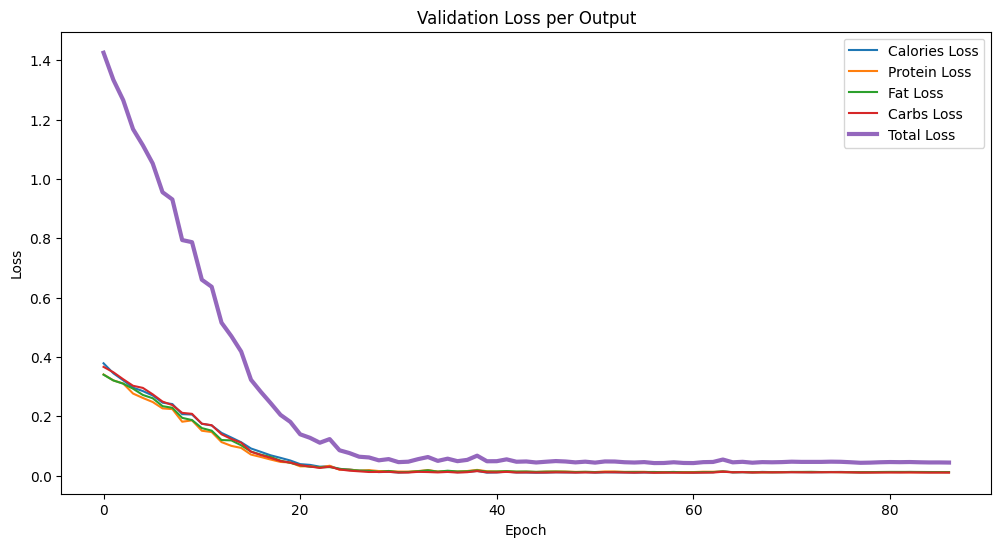

In [28]:
# =========================================================
# DISPLAY AVAILABLE METRICS
# =========================================================

print(mhmo_history.history.keys())

# =========================================================
# GET FINAL VALIDATION LOSS
# =========================================================

calorie_loss = (
    mhmo_history.history[
        'val_calorie_output_loss'
    ][-1]
)

protein_loss = (
    mhmo_history.history[
        'val_protein_output_loss'
    ][-1]
)

fat_loss = (
    mhmo_history.history[
        'val_fat_output_loss'
    ][-1]
)

carbs_loss = (
    mhmo_history.history[
        'val_carbs_output_loss'
    ][-1]
)

total_loss = (
    mhmo_history.history[
        'val_loss'
    ][-1]
)

# =========================================================
# DISPLAY LOSS RESULT
# =========================================================

print(
    "\n========== FINAL VALIDATION LOSS ==========\n"
)

print(
    f"Calories Loss : "
    f"{calorie_loss:.4f}"
)

print(
    f"Protein Loss  : "
    f"{protein_loss:.4f}"
)

print(
    f"Fat Loss      : "
    f"{fat_loss:.4f}"
)

print(
    f"Carbs Loss    : "
    f"{carbs_loss:.4f}"
)

print(
    f"\nTotal Loss    : "
    f"{total_loss:.4f}"
)

print(
    "\n==========================================="
)

# =========================================================
# LOSS VISUALIZATION
# =========================================================

import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.plot(

    mhmo_history.history[
        'val_calorie_output_loss'
    ],

    label='Calories Loss'
)

plt.plot(

    mhmo_history.history[
        'val_protein_output_loss'
    ],

    label='Protein Loss'
)

plt.plot(

    mhmo_history.history[
        'val_fat_output_loss'
    ],

    label='Fat Loss'
)

plt.plot(

    mhmo_history.history[
        'val_carbs_output_loss'
    ],

    label='Carbs Loss'
)

plt.plot(

    mhmo_history.history[
        'val_loss'
    ],

    label='Total Loss',
    linewidth=3
)

plt.title(
    'Validation Loss per Output'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()


========== FINAL VALIDATION MAE ==========

Calories MAE : 0.1068
Protein MAE  : 0.1136
Fat MAE      : 0.1125
Carbs MAE    : 0.1060


Average Validation MAE : 0.1097


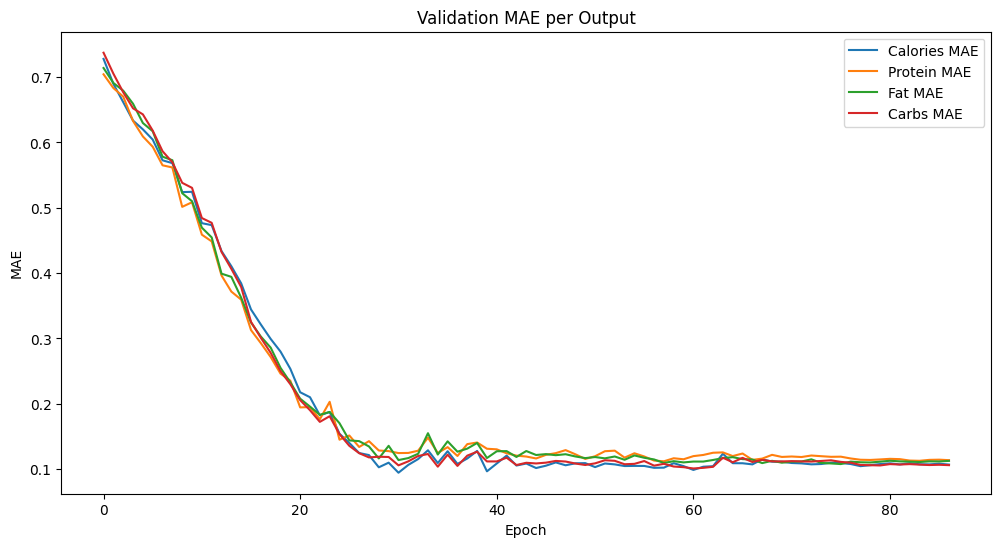

In [30]:
# =========================================================
# GET FINAL VALIDATION MAE
# =========================================================

calorie_mae = (
    mhmo_history.history[
        'val_calorie_output_mae'
    ][-1]
)

protein_mae = (
    mhmo_history.history[
        'val_protein_output_mae'
    ][-1]
)

fat_mae = (
    mhmo_history.history[
        'val_fat_output_mae'
    ][-1]
)

carbs_mae = (
    mhmo_history.history[
        'val_carbs_output_mae'
    ][-1]
)

# =========================================================
# AVERAGE MAE
# =========================================================

average_mae = (

    calorie_mae
    + protein_mae
    + fat_mae
    + carbs_mae

) / 4

# =========================================================
# DISPLAY RESULT
# =========================================================

print(
    "\n========== FINAL VALIDATION MAE ==========\n"
)

print(
    f"Calories MAE : "
    f"{calorie_mae:.4f}"
)

print(
    f"Protein MAE  : "
    f"{protein_mae:.4f}"
)

print(
    f"Fat MAE      : "
    f"{fat_mae:.4f}"
)

print(
    f"Carbs MAE    : "
    f"{carbs_mae:.4f}"
)

print(
    "\n=========================================="
)

print(
    f"\nAverage Validation MAE : "
    f"{average_mae:.4f}"
)

# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(

    mhmo_history.history[
        'val_calorie_output_mae'
    ],

    label='Calories MAE'
)

plt.plot(

    mhmo_history.history[
        'val_protein_output_mae'
    ],

    label='Protein MAE'
)

plt.plot(

    mhmo_history.history[
        'val_fat_output_mae'
    ],

    label='Fat MAE'
)

plt.plot(

    mhmo_history.history[
        'val_carbs_output_mae'
    ],

    label='Carbs MAE'
)

plt.title(
    'Validation MAE per Output'
)

plt.xlabel('Epoch')

plt.ylabel('MAE')

plt.legend()

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


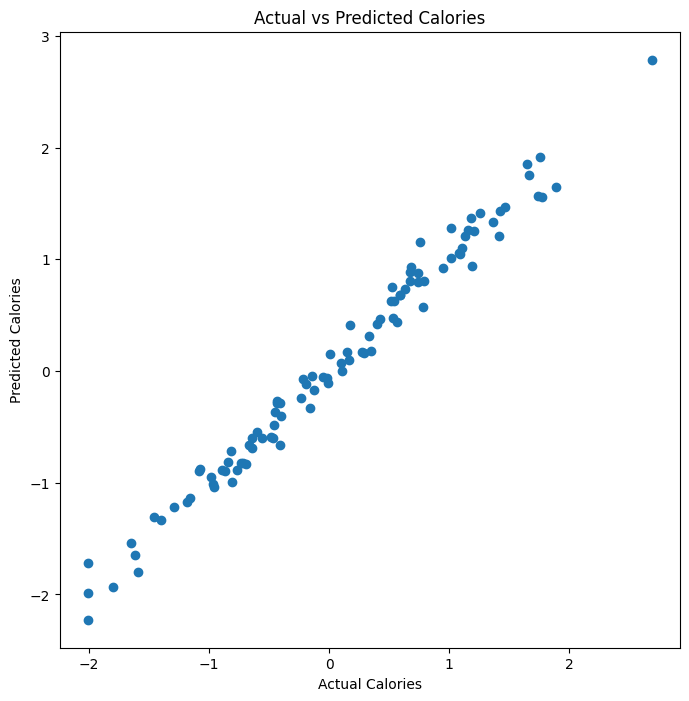

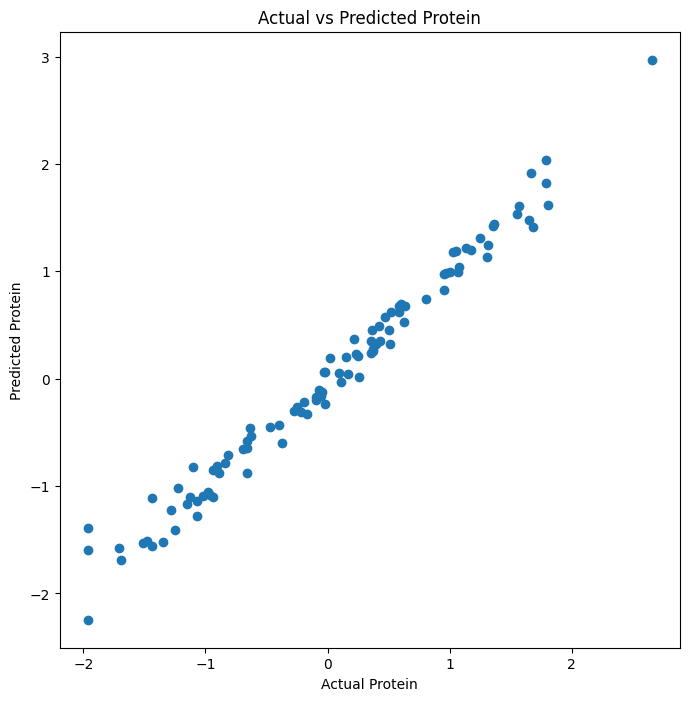

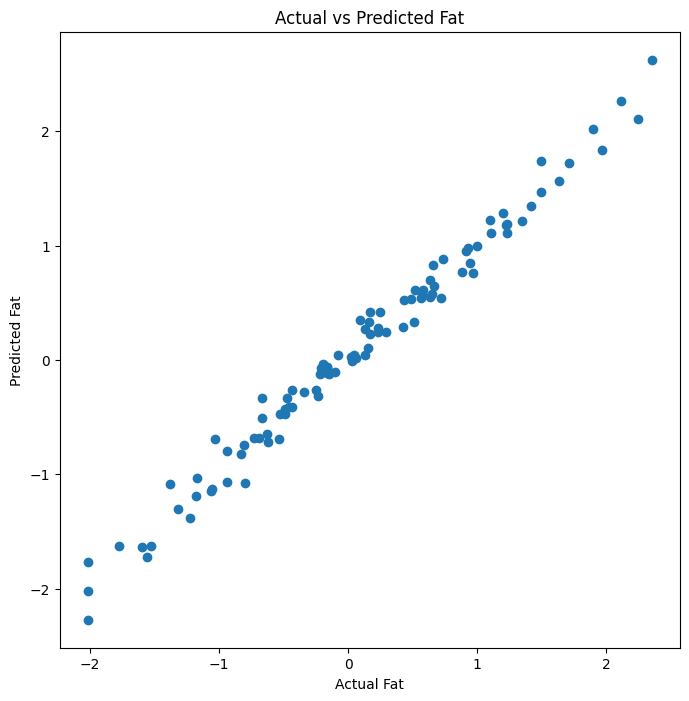

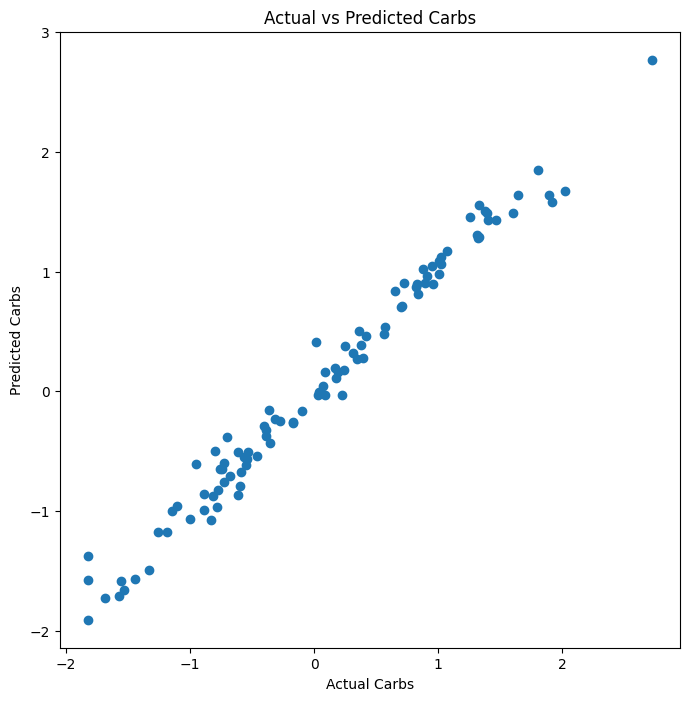

In [32]:
y_pred = mhmo_model.predict(
    X_test
)

# =========================================================
# CALORIES
# =========================================================

plt.figure(figsize=(8,8))

plt.scatter(

    y_test[:, 0],

    y_pred[0]
)

plt.xlabel(
    'Actual Calories'
)

plt.ylabel(
    'Predicted Calories'
)

plt.title(
    'Actual vs Predicted Calories'
)

plt.show()

# =========================================================
# PROTEIN
# =========================================================

plt.figure(figsize=(8,8))

plt.scatter(

    y_test[:, 1],

    y_pred[1]
)

plt.xlabel(
    'Actual Protein'
)

plt.ylabel(
    'Predicted Protein'
)

plt.title(
    'Actual vs Predicted Protein'
)

plt.show()

# =========================================================
# FAT
# =========================================================

plt.figure(figsize=(8,8))

plt.scatter(

    y_test[:, 2],

    y_pred[2]
)

plt.xlabel(
    'Actual Fat'
)

plt.ylabel(
    'Predicted Fat'
)

plt.title(
    'Actual vs Predicted Fat'
)

plt.show()

# =========================================================
# CARBS
# =========================================================

plt.figure(figsize=(8,8))

plt.scatter(

    y_test[:, 3],

    y_pred[3]
)

plt.xlabel(
    'Actual Carbs'
)

plt.ylabel(
    'Predicted Carbs'
)

plt.title(
    'Actual vs Predicted Carbs'
)

plt.show()

In [33]:
print(mhmo_history.history.keys())

dict_keys(['calorie_output_loss', 'calorie_output_mae', 'carbs_output_loss', 'carbs_output_mae', 'fat_output_loss', 'fat_output_mae', 'loss', 'protein_output_loss', 'protein_output_mae', 'val_calorie_output_loss', 'val_calorie_output_mae', 'val_carbs_output_loss', 'val_carbs_output_mae', 'val_fat_output_loss', 'val_fat_output_mae', 'val_loss', 'val_protein_output_loss', 'val_protein_output_mae', 'learning_rate'])


**save model**

In [34]:
os.makedirs('/content/saved_artifacts', exist_ok=True)

mhmo_model.save('/content/saved_artifacts/smart_diet_model.keras')
joblib.dump(preprocessor, '/content/saved_artifacts/preprocessor.pkl')
joblib.dump(mhmo_target_scaler, '/content/saved_artifacts/target_scaler.pkl')

print("Saved successfully")
print("/content/saved_artifacts/smart_diet_model.keras")
print("/content/saved_artifacts/preprocessor.pkl")
print("/content/saved_artifacts/target_scaler.pkl")

Saved successfully
/content/saved_artifacts/smart_diet_model.keras
/content/saved_artifacts/preprocessor.pkl
/content/saved_artifacts/target_scaler.pkl


In [35]:
import joblib
obj = joblib.load("/content/saved_artifacts/preprocessor.pkl")
print(type(obj))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


# Baseline model lama
*Ariel*

Feature and Target Selection

In [36]:
from sklearn.preprocessing import MinMaxScaler

# INPUT FEATURES
X = user_df[
    [
        'gender_encoded',
        'activity_encoded',
        'goal_encoded',
        'weight_kg',
        'height_cm',
        'age'
    ]
]

# TARGETS
y = user_df[
    [
        'calorie_goal',
        'protein_target_g',
        'fat_target_g',
        'carbs_target_g'
    ]
]

print("Feature Shape :", X.shape)

print("Target Shape  :", y.shape)

Feature Shape : (500, 6)
Target Shape  : (500, 4)


Feature Scalling

In [37]:
feature_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)

print("Scaled Feature Shape :", X_scaled.shape)

Scaled Feature Shape : (500, 6)


Target Scalling

In [38]:
target_scaler = MinMaxScaler()

y_scaled = target_scaler.fit_transform(y)

print("Scaled Target Shape :", y_scaled.shape)

Scaled Target Shape : (500, 4)


Split Data

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y_scaled,

    test_size=0.2,

    random_state=42
)

Modelling

In [40]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [41]:
model = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    BatchNormalization(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        4,
        activation='linear'
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile

In [42]:
model.compile(

    optimizer=Adam(
        learning_rate=0.0003
    ),

    loss='mse',

    metrics=['mae']
)

Custom Callback

In [43]:
class CustomTrainingCallback(
    tf.keras.callbacks.Callback
):

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        print(
            f"\nEpoch {epoch+1}"
            f"\nTrain Loss : {logs['loss']:.4f}"
            f"\nTrain MAE  : {logs['mae']:.4f}"
            f"\nVal Loss   : {logs['val_loss']:.4f}"
            f"\nVal MAE    : {logs['val_mae']:.4f}"
        )

In [44]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# EARLY STOPPING
early_stop = EarlyStopping(

    monitor='val_mae',

    patience=20,

    restore_best_weights=True
)

# REDUCE LEARNING RATE
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=10,

    min_lr=1e-6
)

Train

In [45]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=200,

    batch_size=16,

    callbacks=[

        CustomTrainingCallback(),

        early_stop,

        reduce_lr
    ],

    verbose=0
)


Epoch 1
Train Loss : 0.3374
Train MAE  : 0.4661
Val Loss   : 0.2015
Val MAE    : 0.3963

Epoch 2
Train Loss : 0.0949
Train MAE  : 0.2394
Val Loss   : 0.1790
Val MAE    : 0.3710

Epoch 3
Train Loss : 0.0508
Train MAE  : 0.1784
Val Loss   : 0.1701
Val MAE    : 0.3613

Epoch 4
Train Loss : 0.0381
Train MAE  : 0.1562
Val Loss   : 0.1647
Val MAE    : 0.3555

Epoch 5
Train Loss : 0.0298
Train MAE  : 0.1392
Val Loss   : 0.1589
Val MAE    : 0.3494

Epoch 6
Train Loss : 0.0269
Train MAE  : 0.1332
Val Loss   : 0.1571
Val MAE    : 0.3479

Epoch 7
Train Loss : 0.0225
Train MAE  : 0.1205
Val Loss   : 0.1514
Val MAE    : 0.3415

Epoch 8
Train Loss : 0.0199
Train MAE  : 0.1134
Val Loss   : 0.1468
Val MAE    : 0.3364

Epoch 9
Train Loss : 0.0206
Train MAE  : 0.1169
Val Loss   : 0.1404
Val MAE    : 0.3288

Epoch 10
Train Loss : 0.0190
Train MAE  : 0.1118
Val Loss   : 0.1329
Val MAE    : 0.3199

Epoch 11
Train Loss : 0.0187
Train MAE  : 0.1115
Val Loss   : 0.1296
Val MAE    : 0.3160

Epoch 12
Train Los

Evaluate

In [46]:
loss, mae = model.evaluate(
    X_test,
    y_test
)

print(f"Test Loss : {loss}")

print(f"Test MAE  : {mae}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - loss: 0.0137 - mae: 0.0933
Test Loss : 0.01373633835464716
Test MAE  : 0.0933155044913292


Visualitation

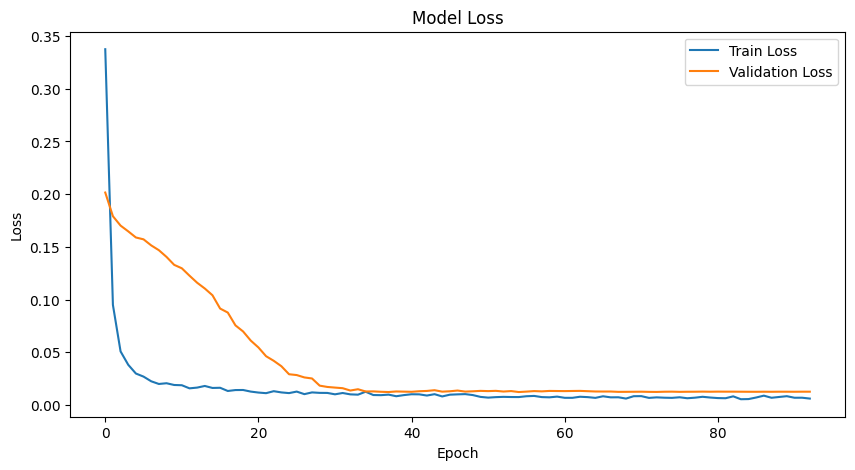

In [47]:
import matplotlib.pyplot as plt

# LOSS
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

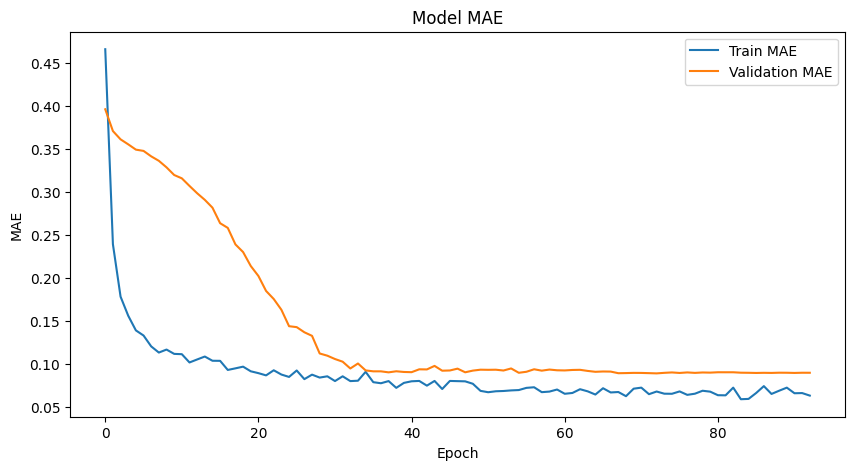

In [48]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['mae'],
    label='Train MAE'
)

plt.plot(
    history.history['val_mae'],
    label='Validation MAE'
)

plt.title('Model MAE')

plt.xlabel('Epoch')

plt.ylabel('MAE')

plt.legend()

plt.show()

In [49]:
# PREDICT
y_pred = model.predict(X_test)

# DATAFRAME
comparison_df = pd.DataFrame({

    'Actual Calories':
        y_test[:, 0],

    'Predicted Calories':
        y_pred[:, 0],

    'Actual Protein':
        y_test[:, 1],

    'Predicted Protein':
        y_pred[:, 1],

    'Actual Fat':
        y_test[:, 2],

    'Predicted Fat':
        y_pred[:, 2],

    'Actual Carbs':
        y_test[:, 3],

    'Predicted Carbs':
        y_pred[:, 3]
})

comparison_df.head(10)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


,Actual Calories,Predicted Calories,Actual Protein,Predicted Protein,Actual Fat,Predicted Fat,Actual Carbs,Predicted Carbs
0,0.585811,0.380444,0.552304,0.335897,0.436234,0.271740,0.623444,0.483629
1,0.180761,0.374790,0.114363,0.355471,0.190703,0.353977,0.191619,0.283172
2,0.089529,0.043008,0.112737,0.021761,0.094160,0.071920,0.063164,0.076646
3,0.300625,0.494620,0.243902,0.418786,0.184744,0.341954,0.364409,0.487794
4,0.129119,0.174271,0.058537,0.174825,0.135876,0.135918,0.149712,0.196852
5,0.398322,0.334566,0.502439,0.508130,0.420739,0.347790,0.281506,0.270772
6,0.739217,0.715059,0.718157,0.661338,0.572110,0.530623,0.762830,0.651764
7,0.197545,0.258248,0.249322,0.337272,0.208582,0.259988,0.139690,0.163948
8,0.377565,0.324880,0.476423,0.493388,0.399285,0.426170,0.266930,0.344869
9,0.327517,0.292983,0.413008,0.425435,0.345650,0.317653,0.231400,0.207567


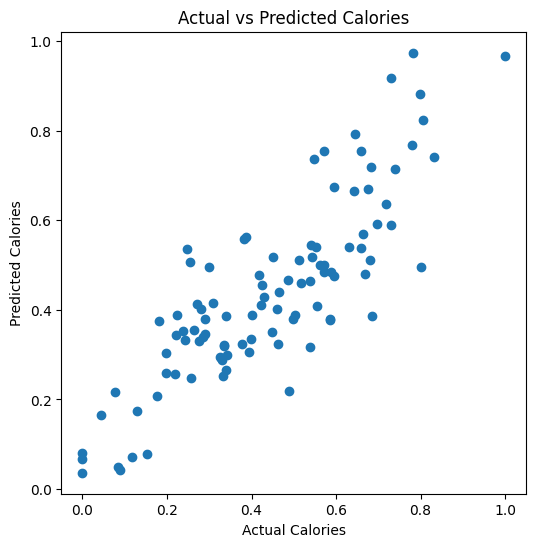

In [50]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,0],
    y_pred[:,0]
)

plt.xlabel('Actual Calories')

plt.ylabel('Predicted Calories')

plt.title('Actual vs Predicted Calories')

plt.show()

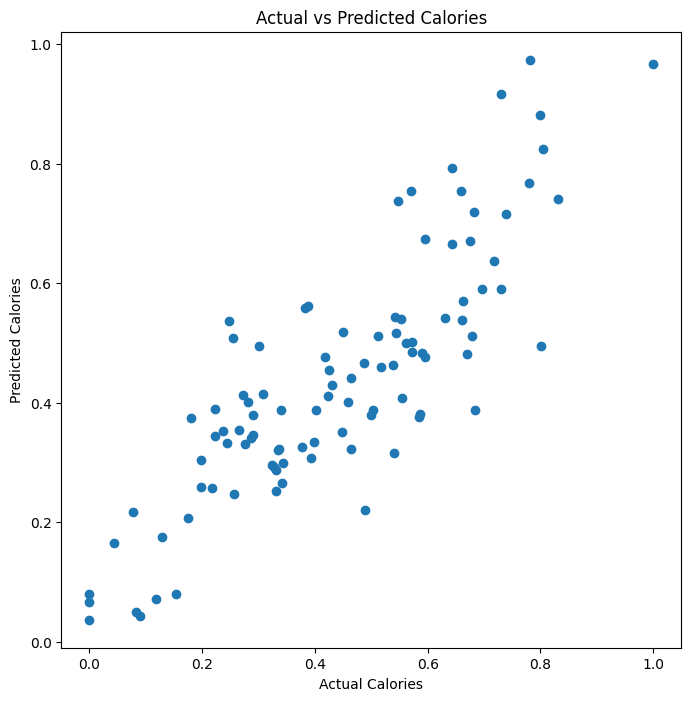

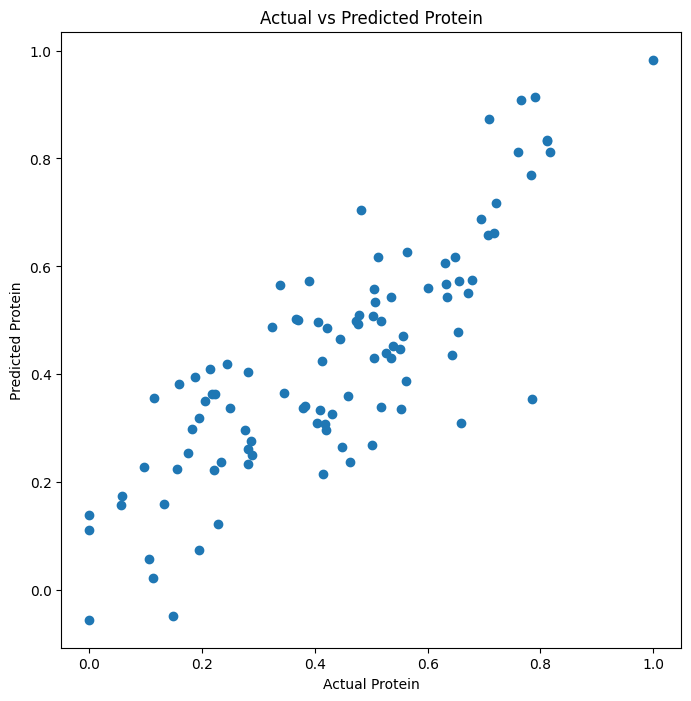

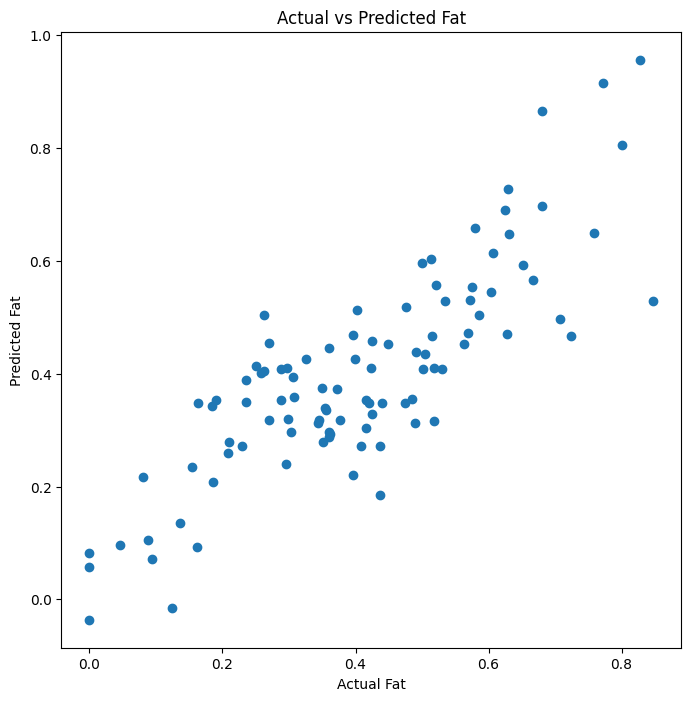

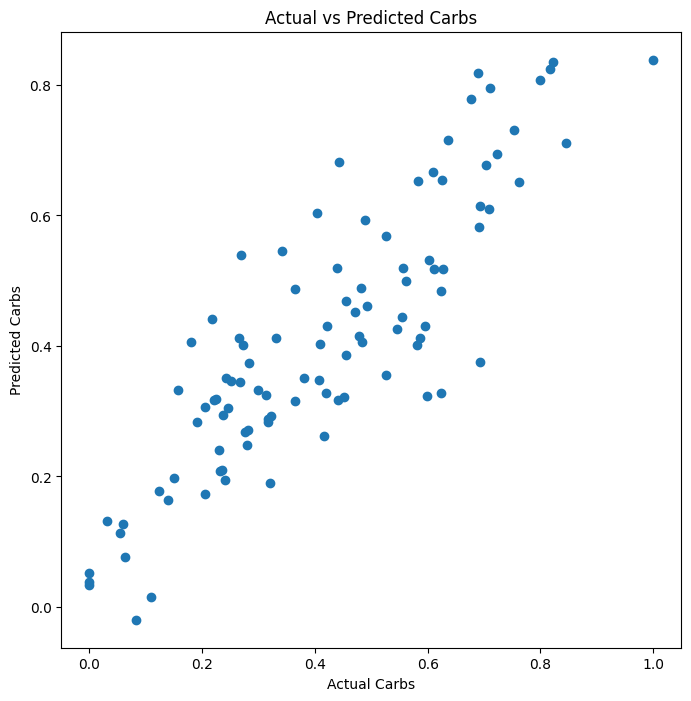

In [51]:
# =========================================================
# ACTUAL VS PREDICTED CALORIES
# =========================================================

plt.figure(figsize=(8,8))

plt.scatter(

    y_test[:, 0],          # actual calories
    y_pred[:, 0]           # predicted calories
)

plt.xlabel(
    'Actual Calories'
)

plt.ylabel(
    'Predicted Calories'
)

plt.title(
    'Actual vs Predicted Calories'
)

plt.show()

# =========================================================
# ACTUAL VS PREDICTED PROTEIN
# =========================================================

plt.figure(figsize=(8,8))

plt.scatter(

    y_test[:, 1],          # actual protein
    y_pred[:, 1]           # predicted protein
)

plt.xlabel(
    'Actual Protein'
)

plt.ylabel(
    'Predicted Protein'
)

plt.title(
    'Actual vs Predicted Protein'
)

plt.show()

# =========================================================
# ACTUAL VS PREDICTED FAT
# =========================================================

plt.figure(figsize=(8,8))

plt.scatter(

    y_test[:, 2],          # actual fat
    y_pred[:, 2]           # predicted fat
)

plt.xlabel(
    'Actual Fat'
)

plt.ylabel(
    'Predicted Fat'
)

plt.title(
    'Actual vs Predicted Fat'
)

plt.show()

# =========================================================
# ACTUAL VS PREDICTED CARBS
# =========================================================

plt.figure(figsize=(8,8))

plt.scatter(

    y_test[:, 3],          # actual carbs
    y_pred[:, 3]           # predicted carbs
)

plt.xlabel(
    'Actual Carbs'
)

plt.ylabel(
    'Predicted Carbs'
)

plt.title(
    'Actual vs Predicted Carbs'
)

plt.show()

Prediction Testing

In [52]:
print(
    user_df[
        ['goal', 'goal_encoded']
    ].drop_duplicates()
)

print(
    user_df[
        ['activity_level', 'activity_encoded']
    ].drop_duplicates()
)

print(
    user_df[
        ['gender', 'gender_encoded']
    ].drop_duplicates()
)

       goal  goal_encoded
0      gain             0
3  maintain             2
4      lose             1
       activity_level  activity_encoded
0           sedentary                 3
2        extra_active                 0
3   moderately_active                 2
6         very_active                 4
11     lightly_active                 1
   gender  gender_encoded
0    male               1
1  female               0


In [53]:
# SAMPLE USER
sample_user = pd.DataFrame([{

    'gender_encoded': 1,
    'activity_encoded': 3,
    'goal_encoded': 1,

    'weight_kg': 70,
    'height_cm': 170,
    'age': 25
}])

# DISPLAY USER INPUT
print("========== USER PROFILE ==========\n")

print("Gender           : Male")

print("Activity Level   : Sedentary")

print("Goal             : Weight Loss")

print("Weight            : 70 kg")

print("Height            : 170 cm")

print("Age               : 25 years")

# FEATURE SCALING
sample_scaled = feature_scaler.transform(
    sample_user
)

# MODEL PREDICTION
prediction_scaled = model.predict(
    sample_scaled
)

# INVERSE TRANSFORM
prediction_real = target_scaler.inverse_transform(
    prediction_scaled
)

# EXTRACT RESULT
calories, protein, fat, carbs = prediction_real[0]

# DISPLAY RESULT
print("\n========== DAILY NUTRITION TARGET ==========\n")

print(f"Daily Calories Target : {calories:.2f} kcal")

print(f"Daily Protein Target  : {protein:.2f} g")

print(f"Daily Fat Target      : {fat:.2f} g")

print(f"Daily Carbs Target    : {carbs:.2f} g")

print("\n============================================")

========== USER PROFILE ==========

Gender           : Male
Activity Level   : Sedentary
Goal             : Weight Loss
Weight            : 70 kg
Height            : 170 cm
Age               : 25 years
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step

========== DAILY NUTRITION TARGET ==========

Daily Calories Target : 1675.49 kcal
Daily Protein Target  : 149.89 g
Daily Fat Target      : 52.20 g
Daily Carbs Target    : 147.61 g



Save Model

In [54]:
model.save(
    'multi_output_regression_model.keras'
)

print(
    "Model saved successfully!"
)

Model saved successfully!


Save Feature Scaler

In [55]:
import joblib

joblib.dump(

    feature_scaler,

    'feature_scaler.pkl'
)

print(
    "Feature scaler saved!"
)

Feature scaler saved!


Save Target Scaler

In [56]:
joblib.dump(

    target_scaler,

    'target_scaler.pkl'
)

print(
    "Target scaler saved!"
)

Target scaler saved!


GOAL BASED PLANNING ENGINE

In [98]:
# =========================================================
# SAMPLE USER INPUT
# =========================================================

sample_user = pd.DataFrame([{

    'gender': 'male',

    'activity_level': 'active',

    'goal': 'weight_loss',

    'weight_kg': 70,

    'height_cm': 170,

    'age': 25,

    'bmr': 1642.5,

    'tdee': 2833.31
}])

# =========================================================
# USER GOAL INPUT
# =========================================================

current_weight = 70

target_weight = 60

# =========================================================
# DISPLAY USER PROFILE
# =========================================================

print("========== USER PROFILE ==========\n")

print("Gender            : Male")

print("Activity Level    : Active")

print("Goal              : Weight Loss")

print("Current Weight    : 70 kg")

print("Target Weight     : 60 kg")

print("Height            : 170 cm")

print("Age               : 25 years")

# =========================================================
# FEATURE SCALING
# =========================================================

sample_scaled = preprocessor.transform(
    sample_user
)

# =========================================================
# MULTI-HEAD PREDICTION
# =========================================================

preds = mhmo_model.predict(
    sample_scaled,
    verbose=0
)

# =========================================================
# COMBINE OUTPUTS
# =========================================================

prediction_scaled = np.column_stack(
    preds
)

# =========================================================
# INVERSE TRANSFORM
# =========================================================

prediction_real = mhmo_target_scaler.inverse_transform(
    prediction_scaled
)

# =========================================================
# EXTRACT BASE TARGET
# =========================================================

calories, protein, fat, carbs = prediction_real[0]

# =========================================================
# DISPLAY BASE TARGET
# =========================================================

print(
    "\n========== BASE NUTRITION TARGET ==========\n"
)

print(
    f"Predicted Calories : "
    f"{calories:.2f} kcal"
)

print(
    f"Predicted Protein  : "
    f"{protein:.2f} g"
)

print(
    f"Predicted Fat      : "
    f"{fat:.2f} g"
)

print(
    f"Predicted Carbs    : "
    f"{carbs:.2f} g"
)

# =========================================================
# DETERMINE GOAL TYPE
# =========================================================

goal_type = sample_user['goal'][0]

# =========================================================
# VALIDATE GOAL
# =========================================================

valid_goals = [

    'weight_loss',

    'weight_gain',

    'maintain'
]

if goal_type not in valid_goals:

    raise ValueError(

        "goal harus salah satu dari: "
        "weight_loss, weight_gain, maintain"
    )

if (
    goal_type == 'weight_loss'
    and target_weight >= current_weight
):

    raise ValueError(

        "Untuk weight_loss, "
        "target_weight harus lebih kecil dari current_weight."
    )

if (
    goal_type == 'weight_gain'
    and target_weight <= current_weight
):

    raise ValueError(

        "Untuk weight_gain, "
        "target_weight harus lebih besar dari current_weight."
    )

if (
    goal_type == 'maintain'
    and target_weight != current_weight
):

    raise ValueError(

        "Untuk maintain, "
        "target_weight harus sama dengan current_weight."
    )

# =========================================================
# WEIGHT DIFFERENCE
# =========================================================

weight_difference = abs(

    current_weight
    - target_weight
)

# =========================================================
# SAFE WEEKLY RATE
# =========================================================

if goal_type == 'weight_loss':

    weekly_rate = 0.75

elif goal_type == 'weight_gain':

    weekly_rate = 0.4

else:

    weekly_rate = 0

# =========================================================
# ESTIMATED DURATION
# =========================================================

if weekly_rate > 0:

    estimated_weeks = (

        weight_difference
        / weekly_rate
    )

    estimated_days = (

        estimated_weeks
        * 7
    )

else:

    estimated_weeks = 0

    estimated_days = 0

# =========================================================
# CALORIE CHANGE
# =========================================================

total_calorie_change = (

    weight_difference
    * 7700
)

if estimated_days > 0:

    daily_calorie_change = (

        total_calorie_change
        / estimated_days
    )

else:

    daily_calorie_change = 0

# =========================================================
# SAFETY LIMIT
# =========================================================

daily_calorie_change = min(

    daily_calorie_change,
    1000
)

# =========================================================
# FINAL CALORIE TARGET
# =========================================================

if goal_type == 'weight_loss':

    adjusted_calories = (

        calories
        - daily_calorie_change
    )

elif goal_type == 'weight_gain':

    adjusted_calories = (

        calories
        + daily_calorie_change
    )

else:

    adjusted_calories = calories

adjusted_calories = max(
    adjusted_calories,
    1200
)

# =========================================================
# MACRO ADJUSTMENT
# =========================================================

protein_ratio = 0.30

fat_ratio = 0.25

carbs_ratio = 0.45

adjusted_protein = (

    adjusted_calories
    * protein_ratio
    / 4
)

adjusted_fat = (

    adjusted_calories
    * fat_ratio
    / 9
)

adjusted_carbs = (

    adjusted_calories
    * carbs_ratio
    / 4
)

# =========================================================
# DISPLAY FINAL TARGET
# =========================================================

print(
    "\n========== GOAL BASED PLANNING ==========\n"
)

print(
    f"Goal Type            : "
    f"{goal_type}"
)

print(
    f"Weight Difference    : "
    f"{weight_difference:.2f} kg"
)

print(
    f"Estimated Duration   : "
    f"{estimated_days:.0f} days"
)

print(
    f"Daily Calorie Change : "
    f"{daily_calorie_change:.2f} kcal"
)

print(
    "\n========== FINAL DAILY TARGET ==========\n"
)

print(
    f"Adjusted Calories : "
    f"{adjusted_calories:.2f} kcal"
)

print(
    f"Adjusted Protein  : "
    f"{adjusted_protein:.2f} g"
)

print(
    f"Adjusted Fat      : "
    f"{adjusted_fat:.2f} g"
)

print(
    f"Adjusted Carbs    : "
    f"{adjusted_carbs:.2f} g"
)

print(
    "\n========================================"
)

========== USER PROFILE ==========

Gender            : Male
Activity Level    : Active
Goal              : Weight Loss
Current Weight    : 70 kg
Target Weight     : 60 kg
Height            : 170 cm
Age               : 25 years

========== BASE NUTRITION TARGET ==========

Predicted Calories : 2663.92 kcal
Predicted Protein  : 202.42 g
Predicted Fat      : 84.86 g
Predicted Carbs    : 276.30 g

========== GOAL BASED PLANNING ==========

Goal Type            : weight_loss
Weight Difference    : 10.00 kg
Estimated Duration   : 93 days
Daily Calorie Change : 825.00 kcal

========== FINAL DAILY TARGET ==========

Adjusted Calories : 1838.92 kcal
Adjusted Protein  : 137.92 g
Adjusted Fat      : 51.08 g
Adjusted Carbs    : 206.88 g



FOOD RECOMMENDATION SYSTEM

Load Data

In [99]:
food_df = pd.read_csv(
    'nutrition_labeled.csv'
)

food_df = (
    food_df
    .dropna()
    .reset_index(drop=True)
)

food_df = food_df[
    food_df[
        'Calories (kcal per 100g)'
    ] < 500
]

food_df = food_df[
    food_df[
        'Protein (g per 100g)'
    ] > 5
].copy()

food_df.head()

,Vitamin C (mg per 100g),Vitamin B11 (mg per 100g),Sodium (mg per 100g),Calcium (mg per 100g),Carbohydrates (g per 100g),food,Iron (mg per 100g),Calories (kcal per 100g),Sugars (g per 100g),Dietary Fiber (g per 100g),...,is_gluten_free,is_lactose_free,is_nut_free,allergen_peanut,allergen_milk,allergen_egg,allergen_fish,allergen_shellfish,allergen_soy,allergen_wheat
57,0.0,0.200,0.060,28.6,62.9,vegetable macaroni dry,3.6,308.0,0.0,3.6,...,True,True,True,False,False,False,False,False,False,False
58,0.0,0.048,0.500,11.2,37.5,chow mein noodles,2.6,257.0,0.5,1.5,...,False,True,True,False,False,False,False,False,False,False
60,0.0,0.045,0.015,14.7,35.7,vegetable macaroni cooked,0.7,172.0,1.5,5.8,...,True,True,True,False,False,False,False,False,False,False
61,0.0,0.048,0.027,4.2,83.2,corn pasta dry,1.0,375.0,0.0,11.6,...,False,True,True,False,False,False,False,False,False,False
62,0.0,0.029,0.095,13.3,27.1,egg noodles dry,0.7,146.0,0.7,1.3,...,False,True,True,False,False,True,False,False,False,False


Meal Category Mapping

In [100]:
def map_meal_category(
    food_name: str
) -> str:

    if pd.isna(food_name):

        return 'lunch'

    name = str(
        food_name
    ).lower().strip()

    breakfast_keywords = [

        'breakfast',
        'bagel',
        'toast',
        'bread',
        'bun',
        'roll',

        'egg',
        'omelet',
        'omelette',
        'scramble',

        'pancake',
        'waffle',

        'porridge',
        'oat',
        'oatmeal',
        'cereal',
        'granola',

        'milk',
        'yogurt',
        'coffee',
        'tea',
        'smoothie',

        'banana',
        'apple',
        'fruit bowl',

        'jam',
        'margarine',
        'butter'
    ]

    snack_keywords = [

        'cake',
        'cookie',
        'biscuit',
        'cracker',
        'chips',
        'popcorn',

        'dessert',
        'ice cream',
        'pudding',

        'chocolate',
        'candy',
        'sweet',

        'burfi',
        'ladoo',
        'halwa',

        'pie',
        'pastry',
        'muffin',
        'brownie',

        'donut',
        'doughnut'
    ]

    dinner_keywords = [

        'grilled chicken',
        'roast chicken',
        'chicken curry',

        'salmon',
        'tuna steak',
        'fish curry',

        'beef stew',

        'stew',
        'curry',
        'soup',
        'broth',

        'ramen',
        'noodle soup',

        'rice bowl',
        'fried rice',

        'biryani',
        'pilaf',

        'tofu',
        'tempeh',

        'stir-fry',
        'sauteed',

        'roasted vegetables',

        'meatball',
        'lasagna',
        'pasta',
        'spaghetti',
        'macaroni',

        'steak',
        'grill',
        'roast',
        'baked'
    ]

    lunch_keywords = [

        'rice',
        'noodle',
        'noodles',

        'sandwich',
        'burger',
        'wrap',

        'salad',

        'chicken',
        'beef',
        'fish',

        'shrimp',
        'prawn',

        'tofu',
        'tempeh',

        'soup',
        'stew',
        'curry',

        'pasta',
        'fried rice',

        'omelette rice',

        'meal',
        'mixed dish'
    ]

    ingredient_keywords = [

        'flour',
        'oil',
        'sugar',
        'syrup',
        'powder',

        'seasoning',
        'extract',
        'shortening',
        'butter oil'
    ]

    if any(
        keyword in name
        for keyword in ingredient_keywords
    ):
        return 'snack'

    if any(
        keyword in name
        for keyword in breakfast_keywords
    ):
        return 'breakfast'

    if any(
        keyword in name
        for keyword in snack_keywords
    ):
        return 'snack'

    if any(
        keyword in name
        for keyword in dinner_keywords
    ):
        return 'dinner'

    if any(
        keyword in name
        for keyword in lunch_keywords
    ):
        return 'lunch'

    return 'lunch'

Apply Meal Category

In [101]:
food_df['meal_category'] = (

    food_df['food_normalized']

    .fillna(
        food_df['food']
    )

    .apply(
        map_meal_category
    )
)

food_df[
    [
        'food',
        'meal_category'
    ]
].head()

,food,meal_category
57,vegetable macaroni dry,dinner
58,chow mein noodles,lunch
60,vegetable macaroni cooked,dinner
61,corn pasta dry,dinner
62,egg noodles dry,breakfast


Food Filtering

In [102]:
def filter_foods_by_preferences(

    data,

    dietary_preferences=None,

    allergies=None
):

    dietary_preferences = (
        dietary_preferences or []
    )

    allergies = allergies or []

    filtered = data.copy()

    for pref in dietary_preferences:

        if pref in filtered.columns:

            filtered = filtered[
                filtered[pref] == True
            ]

    for allergy in allergies:

        if allergy in filtered.columns:

            filtered = filtered[
                filtered[allergy] == False
            ]

    return filtered

Recommendation Score

In [104]:
def calculate_recommendation_score(

    data,

    target_calories,

    target_protein,

    target_fat,

    target_carbs
):

    data = data.copy()

    calorie_score = abs(

        data[
            'Calories (kcal per 100g)'
        ]

        -

        (
            target_calories / 6
        )
    )

    protein_score = abs(

        data[
            'Protein (g per 100g)'
        ]

        -

        (
            target_protein / 6
        )
    )

    fat_score = abs(

        data[
            'Fat (g per 100g)'
        ]

        -

        (
            target_fat / 6
        )
    )

    carbs_score = abs(

        data[
            'Carbohydrates (g per 100g)'
        ]

        -

        (
            target_carbs / 6
        )
    )

    data[
        'recommendation_score'
    ] = (

        calorie_score
        + protein_score
        + fat_score
        + carbs_score
    )

    return data

Apply Foof Penalty

In [105]:
def classify_food_flags(
    food_name: str
) -> dict:

    name = str(
        food_name
    ).lower().strip()

    ingredient_keywords = [

        'flour',
        'oil',
        'sugar',
        'syrup',
        'powder',
        'seasoning',

        'extract',
        'shortening',
        'butter oil',
        'starch'
    ]

    dessert_keywords = [

        'cake',
        'cookie',
        'biscuit',
        'cracker',
        'chips',
        'popcorn',

        'dessert',
        'ice cream',
        'pudding',

        'chocolate',
        'candy',
        'sweet',

        'burfi',
        'ladoo',
        'halwa',

        'pie',
        'pastry',
        'muffin',
        'brownie',

        'donut',
        'doughnut'
    ]

    breakfast_friendly_snack_keywords = [

        'bagel',
        'toast',
        'bread',
        'bun',
        'roll',

        'granola',
        'cereal',

        'oat bar',
        'fruit bar'
    ]

    is_ingredient = any(

        keyword in name

        for keyword in ingredient_keywords
    )

    is_dessert = any(

        keyword in name

        for keyword in dessert_keywords
    )

    is_breakfast_friendly_snack = any(

        keyword in name

        for keyword in breakfast_friendly_snack_keywords
    )

    return {

        'is_ingredient':
        is_ingredient,

        'is_dessert':
        is_dessert,

        'is_breakfast_friendly_snack':
        is_breakfast_friendly_snack
    }

def apply_food_penalty(
    data: pd.DataFrame
) -> pd.DataFrame:

    data = data.copy()

    flags = data[
        'food'
    ].apply(
        classify_food_flags
    )

    flags_df = pd.DataFrame(
        flags.tolist()
    )

    data = pd.concat(

        [
            data.reset_index(drop=True),
            flags_df.reset_index(drop=True)
        ],

        axis=1
    )

    data['penalty_score'] = 0.0

    data.loc[
        data['is_dessert'] == True,
        'penalty_score'
    ] += 35.0

    data.loc[
        data['meal_category'] == 'snack',
        'penalty_score'
    ] += 15.0

    data.loc[
        data['food']
        .astype(str)
        .str.lower()
        .str.split()
        .str.len() <= 1,

        'penalty_score'
    ] += 15.0

    breakfast_bonus_keywords = [

        'egg',
        'omelette',

        'oat',
        'oatmeal',

        'bread',
        'toast',

        'bagel',

        'milk',
        'yogurt',

        'banana',
        'apple',

        'tea',
        'coffee'
    ]

    data['bonus_score'] = data.apply(

        lambda row: -10.0

        if row['meal_category'] == 'breakfast'

        and any(

            keyword in str(
                row['food']
            ).lower()

            for keyword in breakfast_bonus_keywords
        )

        else 0.0,

        axis=1
    )

    data['final_score'] = (

        data['recommendation_score']

        +

        data['penalty_score']

        +

        data['bonus_score']
    )

    return data

Apply Penalty

In [106]:
scored_foods = calculate_recommendation_score(

    food_df,

    adjusted_calories,

    adjusted_protein,

    adjusted_fat,

    adjusted_carbs
)

scored_foods = apply_food_penalty(
    scored_foods
)

scored_foods.head()

,Vitamin C (mg per 100g),Vitamin B11 (mg per 100g),Sodium (mg per 100g),Calcium (mg per 100g),Carbohydrates (g per 100g),food,Iron (mg per 100g),Calories (kcal per 100g),Sugars (g per 100g),Dietary Fiber (g per 100g),...,allergen_soy,allergen_wheat,meal_category,recommendation_score,is_ingredient,is_dessert,is_breakfast_friendly_snack,penalty_score,bonus_score,final_score
0,0.0,0.200,0.060,28.6,62.9,vegetable macaroni dry,3.6,308.0,0.0,3.6,...,False,False,dinner,49.534039,False,False,False,0.0,0.0,49.534039
1,0.0,0.048,0.500,11.2,37.5,chow mein noodles,2.6,257.0,0.5,1.5,...,False,False,lunch,70.979499,False,False,False,0.0,0.0,70.979499
2,0.0,0.045,0.015,14.7,35.7,vegetable macaroni cooked,0.7,172.0,1.5,5.8,...,False,False,dinner,161.006513,False,False,False,0.0,0.0,161.006513
3,0.0,0.048,0.027,4.2,83.2,corn pasta dry,1.0,375.0,0.0,11.6,...,False,False,dinner,138.734039,False,False,False,0.0,0.0,138.734039
4,0.0,0.029,0.095,13.3,27.1,egg noodles dry,0.7,146.0,0.7,1.3,...,False,False,breakfast,192.265917,False,False,False,0.0,-10.0,182.265917


Weighted Random Pick

In [107]:
def weighted_pick(
    data: pd.DataFrame,
    n: int
) -> pd.DataFrame:

    data = data.copy()

    if data.empty:

        return data

    data['sampling_weight'] = (

        1 / (
            data['final_score']
            + 1e-6
        )
    )

    data['sampling_weight'] = (

        data['sampling_weight']

        /

        data['sampling_weight'].sum()
    )

    n = min(
        n,
        len(data)
    )

    return data.sample(

        n=n,

        replace=False,

        weights='sampling_weight',

        random_state=int(
            time.time() * 1000
        ) % 1_000_000
    ).copy()

Pick Meal Candidates

In [108]:
def pick_meal_candidates(

    scored_foods: pd.DataFrame,

    meal_time: str,

    sample_n: int = 2,

    top_n: int = 40
) -> pd.DataFrame:

    candidates = scored_foods.copy()

    candidates = candidates[
        candidates['is_ingredient'] == False
    ].copy()

    if meal_time == 'breakfast':

        main_candidates = candidates[
            candidates['meal_category'] == 'breakfast'
        ].copy()

        snack_candidates = candidates[

            (
                candidates['meal_category']
                == 'snack'
            )

            &

            (
                candidates[
                    'is_breakfast_friendly_snack'
                ] == True
            )
        ].copy()

        main_candidates = (

            main_candidates

            .sort_values(
                by='final_score'
            )

            .head(
                min(
                    top_n,
                    len(main_candidates)
                )
            )
        )

        snack_candidates = (

            snack_candidates

            .sort_values(
                by='final_score'
            )

            .head(
                min(
                    top_n,
                    len(snack_candidates)
                )
            )
        )

        picked_main = weighted_pick(
            main_candidates,
            1
        )

        picked_snack = weighted_pick(
            snack_candidates,
            1
        )

        picked = pd.concat(

            [
                picked_main,
                picked_snack
            ],

            ignore_index=True
        )

        if picked.empty:

            fallback = candidates[
                candidates['meal_category']
                == 'breakfast'
            ].copy()

            fallback = (

                fallback

                .sort_values(
                    by='final_score'
                )

                .head(
                    min(
                        sample_n,
                        len(fallback)
                    )
                )
            )

            picked = fallback

    elif meal_time == 'lunch':

        candidates = candidates[

            (
                candidates['meal_category']
                == 'lunch'
            )

            &

            (
                candidates['is_dessert']
                == False
            )
        ].copy()

        candidates = (

            candidates

            .sort_values(
                by='final_score'
            )

            .head(
                min(
                    top_n,
                    len(candidates)
                )
            )
        )

        picked = weighted_pick(
            candidates,
            sample_n
        )

    elif meal_time == 'dinner':

        candidates = candidates[

            (
                candidates['meal_category']
                == 'dinner'
            )

            &

            (
                candidates['is_dessert']
                == False
            )
        ].copy()

        candidates = (

            candidates

            .sort_values(
                by='final_score'
            )

            .head(
                min(
                    top_n,
                    len(candidates)
                )
            )
        )

        picked = weighted_pick(
            candidates,
            sample_n
        )

    else:

        picked = pd.DataFrame()

    if picked.empty:

        fallback = scored_foods[

            (
                scored_foods['is_ingredient']
                == False
            )

            &

            (
                scored_foods['is_dessert']
                == False
            )
        ].copy()

        fallback = (

            fallback

            .sort_values(
                by='final_score'
            )

            .head(
                min(
                    sample_n,
                    len(fallback)
                )
            )
        )

        picked = fallback

    picked['meal_time'] = (
        meal_time
    )

    return picked

Portion Optimization

In [109]:
from scipy.optimize import minimize

def assign_portion_grams(

    top_foods,

    target_calories,

    target_protein,

    target_fat,

    target_carbs
):

    top_foods = top_foods.copy()

    calories_arr = top_foods[
        'Calories (kcal per 100g)'
    ].values

    protein_arr = top_foods[
        'Protein (g per 100g)'
    ].values

    fat_arr = top_foods[
        'Fat (g per 100g)'
    ].values

    carbs_arr = top_foods[
        'Carbohydrates (g per 100g)'
    ].values

    def objective(portions):

        total_calories = np.sum(
            portions * calories_arr / 100
        )

        total_protein = np.sum(
            portions * protein_arr / 100
        )

        total_fat = np.sum(
            portions * fat_arr / 100
        )

        total_carbs = np.sum(
            portions * carbs_arr / 100
        )

        return (

            (total_calories - target_calories) ** 2

            +

            (total_protein - target_protein) ** 2

            +

            (total_fat - target_fat) ** 2

            +

            (total_carbs - target_carbs) ** 2
        )

    initial_guess = np.array(
        [100] * len(top_foods)
    )

    bounds = [

        (50, 400)

        for _ in range(
            len(top_foods)
        )
    ]

    result = minimize(

        objective,

        initial_guess,

        bounds=bounds,

        method='L-BFGS-B'
    )

    top_foods[
        'recommended_grams'
    ] = result.x

    return top_foods

Format Result

In [110]:
def format_meal_items(
    data: pd.DataFrame
) -> list:

    items = []

    for _, row in data.iterrows():

        items.append({

            'food': row['food'],

            'meal_time': row['meal_time'],

            'meal_category': row['meal_category'],

            'recommended_grams': int(
                round(
                    row['recommended_grams']
                )
            ),

            'estimated_calories': float(

                round(

                    (
                        row['recommended_grams']
                        *
                        row[
                            'Calories (kcal per 100g)'
                        ]
                    ) / 100,

                    2
                )
            ),

            'protein_per_100g': float(
                row[
                    'Protein (g per 100g)'
                ]
            ),

            'fat_per_100g': float(
                row[
                    'Fat (g per 100g)'
                ]
            ),

            'carbs_per_100g': float(
                row[
                    'Carbohydrates (g per 100g)'
                ]
            ),

            'final_score': float(
                round(
                    row['final_score'],
                    2
                )
            )
        })

    return items

Breakfast

In [111]:
breakfast_foods = pick_meal_candidates(

    scored_foods,

    'breakfast',

    sample_n=2,

    top_n=40
)

breakfast_foods = assign_portion_grams(

    breakfast_foods,

    adjusted_calories * 0.25,

    adjusted_protein * 0.25,

    adjusted_fat * 0.25,

    adjusted_carbs * 0.25
)

format_meal_items(
    breakfast_foods
)

[{'food': 'Black forest gateau',
  'meal_time': 'breakfast',
  'meal_category': 'breakfast',
  'recommended_grams': 210,
  'estimated_calories': 458.35,
  'protein_per_100g': 5.94,
  'fat_per_100g': 8.58,
  'carbs_per_100g': 30.57,
  'final_score': 99.69}]

Lunch

In [112]:
lunch_foods = pick_meal_candidates(

    scored_foods,

    'lunch',

    sample_n=2,

    top_n=40
)

lunch_foods = assign_portion_grams(

    lunch_foods,

    adjusted_calories * 0.35,

    adjusted_protein * 0.35,

    adjusted_fat * 0.35,

    adjusted_carbs * 0.35
)

format_meal_items(
    lunch_foods
)

[{'food': 'burrito with beef',
  'meal_time': 'lunch',
  'meal_category': 'lunch',
  'recommended_grams': 173,
  'estimated_calories': 492.64,
  'protein_per_100g': 9.1,
  'fat_per_100g': 8.1,
  'carbs_per_100g': 43.9,
  'final_score': 45.21},
 {'food': 'Namkeen daliya',
  'meal_time': 'lunch',
  'meal_category': 'lunch',
  'recommended_grams': 50,
  'estimated_calories': 147.56,
  'protein_per_100g': 8.29,
  'fat_per_100g': 7.99,
  'carbs_per_100g': 49.32,
  'final_score': 41.44}]

Dinner

In [113]:
dinner_foods = pick_meal_candidates(

    scored_foods,

    'dinner',

    sample_n=2,

    top_n=40
)

dinner_foods = assign_portion_grams(

    dinner_foods,

    adjusted_calories * 0.40,

    adjusted_protein * 0.40,

    adjusted_fat * 0.40,

    adjusted_carbs * 0.40
)

format_meal_items(
    dinner_foods
)

[{'food': 'macaroni cheese',
  'meal_time': 'dinner',
  'meal_category': 'dinner',
  'recommended_grams': 191,
  'estimated_calories': 592.99,
  'protein_per_100g': 12.6,
  'fat_per_100g': 9.4,
  'carbs_per_100g': 43.7,
  'final_score': 24.01},
 {'food': 'tomato beef noodle soup',
  'meal_time': 'dinner',
  'meal_category': 'dinner',
  'recommended_grams': 50,
  'estimated_calories': 140.5,
  'protein_per_100g': 8.9,
  'fat_per_100g': 8.6,
  'carbs_per_100g': 42.3,
  'final_score': 47.48}]

Recommendation Demo

In [114]:
meal_plan_result = {

    'breakfast': format_meal_items(
        breakfast_foods
    ),

    'lunch': format_meal_items(
        lunch_foods
    ),

    'dinner': format_meal_items(
        dinner_foods
    )
}

print(
    "========== FINAL MEAL PLAN ==========\n"
)

for meal_time, items in (
    meal_plan_result.items()
):

    print(
        f"\n===== "
        f"{meal_time.upper()} "
        f"=====\n"
    )

    for item in items:

        print(

            f"- {item['food']} "

            f"| {item['recommended_grams']}g "

            f"| {item['estimated_calories']} kcal"
        )

========== FINAL MEAL PLAN ==========


===== BREAKFAST =====

- Black forest gateau | 210g | 458.35 kcal

===== LUNCH =====

- burrito with beef | 173g | 492.64 kcal
- Namkeen daliya | 50g | 147.56 kcal

===== DINNER =====

- macaroni cheese | 191g | 592.99 kcal
- tomato beef noodle soup | 50g | 140.5 kcal


Simulation

Load Model

In [116]:
from tensorflow.keras.models import load_model

import joblib

mhmo_model = load_model(
    'saved_artifacts/smart_diet_model.keras'
)

preprocessor = joblib.load(
    'saved_artifacts/preprocessor.pkl'
)

mhmo_target_scaler = joblib.load(
    'saved_artifacts/target_scaler.pkl'
)

print(
    "MHMO exported model loaded successfully."
)

MHMO exported model loaded successfully.


User Input

In [117]:
user_input = {

    'gender': 'male',

    'activity_level': 'moderate',

    'goal': 'weight_loss',

    'weight_kg': 85,

    'target_weight': 75,

    'height_cm': 175,

    'age': 24,

    'dietary_preferences': [

        'is_halal'
    ],

    'allergies': [

        'allergen_milk'
    ]
}

print(
    user_input
)

{'gender': 'male', 'activity_level': 'moderate', 'goal': 'weight_loss', 'weight_kg': 85, 'target_weight': 75, 'height_cm': 175, 'age': 24, 'dietary_preferences': ['is_halal'], 'allergies': ['allergen_milk']}


BMR & TDEE Calculation

In [118]:
def calculate_bmr(

    weight_kg: float,

    height_cm: float,

    age: int,

    gender: str
) -> float:

    gender = gender.lower()

    if gender == 'male':

        return (

            (10 * weight_kg)

            +

            (6.25 * height_cm)

            -

            (5 * age)

            +

            5
        )

    elif gender == 'female':

        return (

            (10 * weight_kg)

            +

            (6.25 * height_cm)

            -

            (5 * age)

            -

            161
        )

    else:

        raise ValueError(
            "gender harus male atau female"
        )

def calculate_tdee(

    bmr: float,

    activity_level: str
) -> float:

    activity_map = {

        'sedentary': 1.2,

        'light': 1.375,

        'moderate': 1.55,

        'active': 1.725,

        'very_active': 1.9
    }

    return (

        bmr *

        activity_map[
            activity_level
        ]
    )

bmr = calculate_bmr(

    weight_kg=user_input['weight_kg'],

    height_cm=user_input['height_cm'],

    age=user_input['age'],

    gender=user_input['gender']
)

tdee = calculate_tdee(

    bmr=bmr,

    activity_level=user_input['activity_level']
)

print(
    f"BMR  : {bmr:.2f}"
)

print(
    f"TDEE : {tdee:.2f}"
)

BMR  : 1828.75
TDEE : 2834.56


Model Inference

In [119]:
sample_user = pd.DataFrame([{

    'gender': user_input['gender'],

    'weight_kg': user_input['weight_kg'],

    'height_cm': user_input['height_cm'],

    'age': user_input['age'],

    'activity_level': user_input['activity_level'],

    'goal': user_input['goal'],

    'bmr': bmr,

    'tdee': tdee
}])

sample_processed = preprocessor.transform(
    sample_user
)

if hasattr(
    sample_processed,
    "toarray"
):

    sample_processed = (
        sample_processed.toarray()
    )

preds = mhmo_model.predict(

    sample_processed,

    verbose=0
)

pred_scaled = np.column_stack(
    preds
)

pred = mhmo_target_scaler.inverse_transform(
    pred_scaled
)[0]

calories = pred[0]

protein = pred[1]

fat = pred[2]

carbs = pred[3]

print(
    "\n========== MODEL PREDICTION ==========\n"
)

print(
    f"Calories : {calories:.2f}"
)

print(
    f"Protein  : {protein:.2f}"
)

print(
    f"Fat      : {fat:.2f}"
)

print(
    f"Carbs    : {carbs:.2f}"
)


========== MODEL PREDICTION ==========

Calories : 2562.41
Protein  : 208.83
Fat      : 86.07
Carbs    : 284.55


Goal Validation

In [120]:
goal_type = user_input[
    'goal'
].lower()

current_weight = user_input[
    'weight_kg'
]

target_weight = user_input[
    'target_weight'
]

if (

    goal_type == 'weight_loss'

    and

    target_weight >= current_weight
):

    raise ValueError(

        "Untuk weight_loss, "

        "target_weight harus lebih kecil "

        "dari weight_kg."
    )

if (

    goal_type == 'weight_gain'

    and

    target_weight <= current_weight
):

    raise ValueError(

        "Untuk weight_gain, "

        "target_weight harus lebih besar "

        "dari weight_kg."
    )

if (

    goal_type == 'maintain'

    and

    target_weight != current_weight
):

    raise ValueError(

        "Untuk maintain, "

        "target_weight harus sama "

        "dengan weight_kg."
    )

print(
    "Goal validation passed."
)

Goal validation passed.


Goal Based Adjustment

In [121]:
weight_difference = abs(

    current_weight
    -
    target_weight
)

if goal_type == 'weight_loss':

    weekly_rate = 0.75

elif goal_type == 'weight_gain':

    weekly_rate = 0.4

else:

    weekly_rate = 0

estimated_days = (

    (weight_difference / weekly_rate) * 7

    if weekly_rate > 0

    else 0
)

total_calorie_change = (

    weight_difference * 7700
)

daily_calorie_change = (

    total_calorie_change / estimated_days

    if estimated_days > 0

    else 0
)

daily_calorie_change = min(

    daily_calorie_change,

    1000
)

if goal_type == 'weight_loss':

    adjusted_calories = (

        calories
        -
        daily_calorie_change
    )

elif goal_type == 'weight_gain':

    adjusted_calories = (

        calories
        +
        daily_calorie_change
    )

else:

    adjusted_calories = calories

adjusted_calories = max(

    adjusted_calories,

    1200
)

protein_ratio = 0.30

fat_ratio = 0.25

carbs_ratio = 0.45

adjusted_protein = (

    adjusted_calories
    *
    protein_ratio
    / 4
)

adjusted_fat = (

    adjusted_calories
    *
    fat_ratio
    / 9
)

adjusted_carbs = (

    adjusted_calories
    *
    carbs_ratio
    / 4
)

print(
    "\n========== FINAL DAILY TARGET ==========\n"
)

print(
    f"Calories : {adjusted_calories:.2f}"
)

print(
    f"Protein  : {adjusted_protein:.2f}"
)

print(
    f"Fat      : {adjusted_fat:.2f}"
)

print(
    f"Carbs    : {adjusted_carbs:.2f}"
)

print(
    f"Estimated Days : {estimated_days:.0f}"
)


========== FINAL DAILY TARGET ==========

Calories : 1737.41
Protein  : 130.31
Fat      : 48.26
Carbs    : 195.46
Estimated Days : 93


Apply Filtering

In [122]:
filtered_foods = filter_foods_by_preferences(

    food_df,

    dietary_preferences=user_input[
        'dietary_preferences'
    ],

    allergies=user_input[
        'allergies'
    ]
)

print(
    f"Filtered Foods : {len(filtered_foods)}"
)

Filtered Foods : 949


Apply Recommendation Score

In [123]:
scored_foods = calculate_recommendation_score(

    filtered_foods,

    adjusted_calories,

    adjusted_protein,

    adjusted_fat,

    adjusted_carbs
)

scored_foods = apply_food_penalty(
    scored_foods
)

scored_foods.head()

,Vitamin C (mg per 100g),Vitamin B11 (mg per 100g),Sodium (mg per 100g),Calcium (mg per 100g),Carbohydrates (g per 100g),food,Iron (mg per 100g),Calories (kcal per 100g),Sugars (g per 100g),Dietary Fiber (g per 100g),...,allergen_soy,allergen_wheat,meal_category,recommendation_score,is_ingredient,is_dessert,is_breakfast_friendly_snack,penalty_score,bonus_score,final_score
0,0.0,0.200,0.060,28.6,62.9,vegetable macaroni dry,3.6,308.0,0.0,3.6,...,False,False,dinner,66.616301,False,False,False,0.0,0.0,66.616301
1,0.0,0.048,0.500,11.2,37.5,chow mein noodles,2.6,257.0,0.5,1.5,...,False,False,lunch,55.166067,False,False,False,0.0,0.0,55.166067
2,0.0,0.045,0.015,14.7,35.7,vegetable macaroni cooked,0.7,172.0,1.5,5.8,...,False,False,dinner,144.253202,False,False,False,0.0,0.0,144.253202
3,0.0,0.048,0.027,4.2,83.2,corn pasta dry,1.0,375.0,0.0,11.6,...,False,False,dinner,155.816301,False,False,False,0.0,0.0,155.816301
4,0.0,0.029,0.095,13.3,27.1,egg noodles dry,0.7,146.0,0.7,1.3,...,False,False,breakfast,171.706103,False,False,False,0.0,-10.0,161.706103


Meal Generation

In [124]:
#Breakfast
breakfast_foods = pick_meal_candidates(

    scored_foods,

    'breakfast',

    sample_n=2,

    top_n=40
)

breakfast_foods = assign_portion_grams(

    breakfast_foods,

    adjusted_calories * 0.25,

    adjusted_protein * 0.25,

    adjusted_fat * 0.25,

    adjusted_carbs * 0.25
)

breakfast_result = format_meal_items(
    breakfast_foods
)

breakfast_result

#Lunch
lunch_foods = pick_meal_candidates(

    scored_foods,

    'lunch',

    sample_n=2,

    top_n=40
)

lunch_foods = assign_portion_grams(

    lunch_foods,

    adjusted_calories * 0.35,

    adjusted_protein * 0.35,

    adjusted_fat * 0.35,

    adjusted_carbs * 0.35
)

lunch_result = format_meal_items(
    lunch_foods
)

lunch_result

#dinner
dinner_foods = pick_meal_candidates(

    scored_foods,

    'dinner',

    sample_n=2,

    top_n=40
)

dinner_foods = assign_portion_grams(

    dinner_foods,

    adjusted_calories * 0.40,

    adjusted_protein * 0.40,

    adjusted_fat * 0.40,

    adjusted_carbs * 0.40
)

dinner_result = format_meal_items(
    dinner_foods
)

dinner_result

[{'food': 'spaghetti with meat sauce',
  'meal_time': 'dinner',
  'meal_category': 'dinner',
  'recommended_grams': 163,
  'estimated_calories': 415.5,
  'protein_per_100g': 14.3,
  'fat_per_100g': 2.9,
  'carbs_per_100g': 43.1,
  'final_score': 57.65},
 {'food': 'azumaya tofu vitasoy',
  'meal_time': 'dinner',
  'meal_category': 'dinner',
  'recommended_grams': 88,
  'estimated_calories': 279.43,
  'protein_per_100g': 32.8,
  'fat_per_100g': 16.6,
  'carbs_per_100g': 9.1,
  'final_score': 69.55}]

In [125]:
meal_plan_result = {

    'breakfast': breakfast_result,

    'lunch': lunch_result,

    'dinner': dinner_result
}

print(
    "========== FINAL MEAL PLAN ==========\n"
)

for meal_time, items in (

    meal_plan_result.items()
):

    print(
        f"\n===== "
        f"{meal_time.upper()} "
        f"=====\n"
    )

    for item in items:

        print(

            f"- {item['food']} "

            f"| {item['recommended_grams']}g "

            f"| {item['estimated_calories']} kcal"
        )

========== FINAL MEAL PLAN ==========


===== BREAKFAST =====

- egg custard | 148g | 434.9 kcal

===== LUNCH =====

- Chicken walnut sandwich (Chicken aur akhrot ke sandwich) | 92g | 261.7 kcal
- pepperoni pizza pizza hut | 129g | 347.93 kcal

===== DINNER =====

- spaghetti with meat sauce | 163g | 415.5 kcal
- azumaya tofu vitasoy | 88g | 279.43 kcal
